In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make plots look nice
plt.style.use("seaborn-v0_8")

In [ ]:
data = pd.read_csv("/baseline_example.csv")
# Look at the first few rows
#data.head()
print("Columns:", list(data.columns))
print("\nDtypes:\n", data.dtypes)
print("\nFirst 5 rows:\n", data.head())


Columns: ['date', 'daily_return', 'equity']

Dtypes:
 date             object
daily_return    float64
equity          float64
dtype: object

First 5 rows:
      date  daily_return    equity
0  7/3/25      0.008753  1.008753
1  7/4/25     -0.002030  1.006705
2  7/7/25      0.000464  1.007172
3  7/8/25      0.002338  1.009527
4  7/9/25     -0.003645  1.005847


/tmp/ipython-input-3645158300.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['date'] = pd.to_datetime(data['date'])


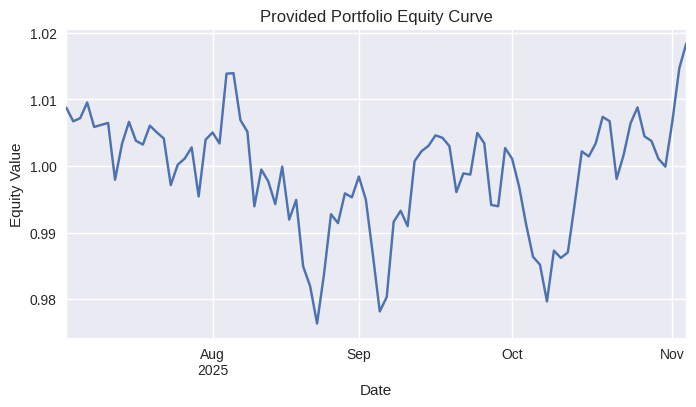

,daily_return,equity
date,,
2025-07-03,0.008753,1.008753
2025-07-04,-0.002030,1.006705
2025-07-07,0.000464,1.007172
2025-07-08,0.002338,1.009527
2025-07-09,-0.003645,1.005847


In [ ]:
#convert date to datetime and set it as index
data['date'] = pd.to_datetime(data['date'])
data = data.set_index('date').sort_index()

# Plot the equity curve
data['equity'].plot(title = "Provided Portfolio Equity Curve", figsize = (8,4))
plt.xlabel("Date")
plt.ylabel("Equity Value")
plt.show()

data.head()

In [ ]:
#Calculate Performance Metrics
daily_return = data['daily_return'].dropna()

#Annualized Return
annual_return = (1+daily_return).prod() ** (252/ len(daily_return)) - 1
#Annualized Volatility
annual_volatility = daily_return.std() * np.sqrt(252)

sharpe = annual_return/annual_volatility

print(f'Annualized Return: {annual_return:.2%}')
print(f'Annualized Volatility: {annual_volatility:.2%}')
print(f'Sharpe Ratio: {sharpe:.2%}')

Annualized Return: 5.23%
Annualized Volatility: 8.26%
Sharpe Ratio: 63.35%
